# Solutions: Potential Outcomes Framework Exercises

Complete solutions to exercises from `potential_outcomes_exercises.ipynb`.

**Note**: Try to solve the exercises yourself before looking at these solutions!

---

## Setup

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style and random seed
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print("Setup complete!")

Setup complete!


---

## Solution 1: Reverse Selection Bias

In [2]:
# Solution to Exercise 1
np.random.seed(42)

# Step 1: Generate data
n = 100
Y0 = np.random.normal(35, 5, n)
Y1 = Y0 + 5  # Constant treatment effect of 5

# Step 2: Reverse selection - low Y0 more likely to be treated
Y0_normalized = (Y0 - Y0.mean()) / Y0.std()
prob_treatment = 1 / (1 + np.exp(+Y0_normalized))  # Note: + sign reverses selection
T = np.random.binomial(1, prob_treatment)

# Observed outcomes
Y_obs = np.where(T == 1, Y1, Y0)

# Step 3: Calculate naive estimate
treated_mean = Y_obs[T == 1].mean()
control_mean = Y_obs[T == 0].mean()
naive_estimate = treated_mean - control_mean

# Step 4: Compare to true ATE
true_ATE = 5.0
baseline_diff = Y0[T == 1].mean() - Y0[T == 0].mean()

print("REVERSE SELECTION BIAS RESULTS:")
print(f"\nTrue ATE: ${true_ATE:.2f}k")
print(f"Naive Estimate: ${naive_estimate:.2f}k")
print(f"Bias: ${naive_estimate - true_ATE:.2f}k")
print(f"\nBaseline difference E[Y(0)|T=1] - E[Y(0)|T=0]: ${baseline_diff:.2f}k")

if naive_estimate < true_ATE:
    print(f"\n⚠️ The naive estimator UNDERESTIMATES the treatment effect!")
    print(f"This is because treated people would have earned LESS even without training.")
    print(f"Low earners were more likely to get treatment, pulling down the treated group average.")
else:
    print(f"\nNaive estimator overestimates (or approximately unbiased due to sampling variation).")

REVERSE SELECTION BIAS RESULTS:

True ATE: $5.00k
Naive Estimate: $1.27k
Bias: $-3.73k

Baseline difference E[Y(0)|T=1] - E[Y(0)|T=0]: $-3.73k

⚠️ The naive estimator UNDERESTIMATES the treatment effect!
This is because treated people would have earned LESS even without training.
Low earners were more likely to get treatment, pulling down the treated group average.


**Discussion**:
- When **low** baseline earners are more likely to be treated, the naive estimator **underestimates**
- The treated group has lower Y(0) on average than the control group
- This negative selection bias reduces the apparent treatment effect
- Real-world example: Programs targeting disadvantaged populations may appear less effective than they actually are due to this bias

---

## Solution 2: Sample Size and Precision

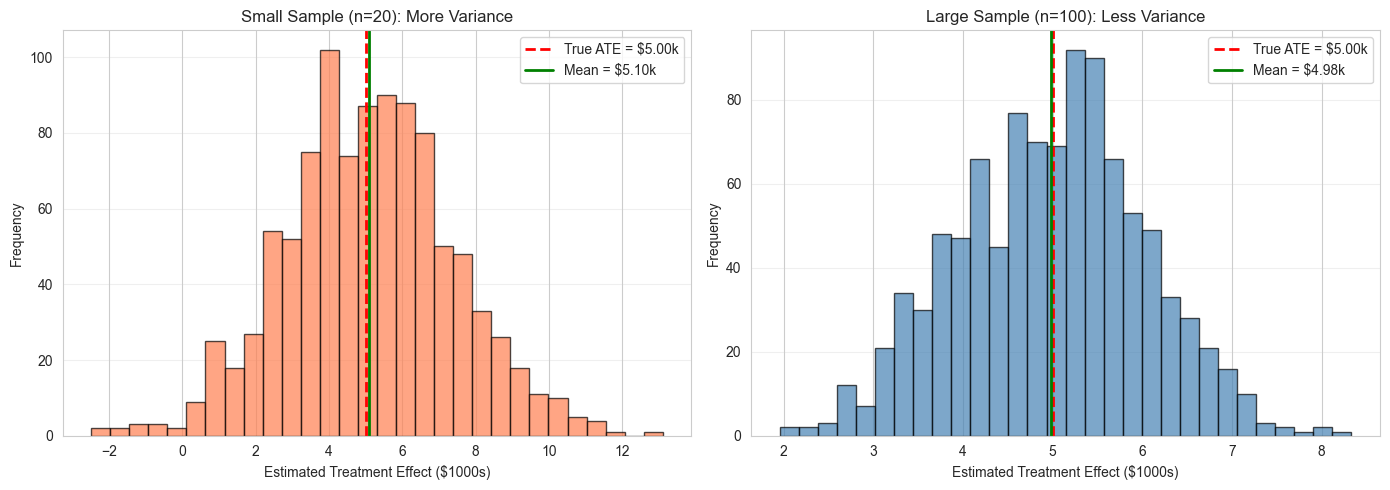

SAMPLE SIZE COMPARISON:

True ATE: $5.00k

Small Sample (n=20):
  Mean estimate: $5.10k
  Bias: $0.10k (close to 0 ✓)
  Standard deviation: $2.30k (HIGH variance)

Large Sample (n=100):
  Mean estimate: $4.98k
  Bias: $-0.02k (close to 0 ✓)
  Standard deviation: $1.04k (LOW variance)

Variance ratio (small/large): 2.21x

🔑 Key Insights:
   • BIAS is ~0 for both (randomization works regardless of sample size)
   • VARIANCE is 2.2x larger with small samples
   • Small samples: estimates spread out more (less precise)
   • Large samples: estimates cluster tighter around true ATE (more precise)


In [3]:
# Solution to Exercise 2
np.random.seed(42)

# Step 1: Define simulation function
def simulate_experiment(n, true_ate):
    """Simulate a randomized experiment."""
    Y0 = np.random.normal(35, 5, n)
    effects = np.random.normal(true_ate, 1, n)
    Y1 = Y0 + effects
    
    # Random assignment
    T = np.random.binomial(1, 0.5, n)
    
    # Observed outcomes
    Y_obs = np.where(T == 1, Y1, Y0)
    
    # Naive estimate
    estimate = Y_obs[T == 1].mean() - Y_obs[T == 0].mean()
    return estimate

# Step 2: Run experiments with different sample sizes
n_experiments = 1000
true_ate = 5.0

estimates_small = [simulate_experiment(20, true_ate) for _ in range(n_experiments)]
estimates_large = [simulate_experiment(100, true_ate) for _ in range(n_experiments)]

estimates_small = np.array(estimates_small)
estimates_large = np.array(estimates_large)

# Step 3: Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Small sample
axes[0].hist(estimates_small, bins=30, alpha=0.7, color='coral', edgecolor='black')
axes[0].axvline(true_ate, color='red', linestyle='--', linewidth=2, label=f'True ATE = ${true_ate:.2f}k')
axes[0].axvline(estimates_small.mean(), color='green', linestyle='-', linewidth=2,
                label=f'Mean = ${estimates_small.mean():.2f}k')
axes[0].set_xlabel('Estimated Treatment Effect ($1000s)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Small Sample (n=20): More Variance')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Large sample
axes[1].hist(estimates_large, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].axvline(true_ate, color='red', linestyle='--', linewidth=2, label=f'True ATE = ${true_ate:.2f}k')
axes[1].axvline(estimates_large.mean(), color='green', linestyle='-', linewidth=2,
                label=f'Mean = ${estimates_large.mean():.2f}k')
axes[1].set_xlabel('Estimated Treatment Effect ($1000s)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Large Sample (n=100): Less Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Step 4: Calculate statistics
print("SAMPLE SIZE COMPARISON:\n")
print(f"True ATE: ${true_ate:.2f}k\n")

print("Small Sample (n=20):")
print(f"  Mean estimate: ${estimates_small.mean():.2f}k")
print(f"  Bias: ${estimates_small.mean() - true_ate:.2f}k (close to 0 ✓)")
print(f"  Standard deviation: ${estimates_small.std():.2f}k (HIGH variance)")

print("\nLarge Sample (n=100):")
print(f"  Mean estimate: ${estimates_large.mean():.2f}k")
print(f"  Bias: ${estimates_large.mean() - true_ate:.2f}k (close to 0 ✓)")
print(f"  Standard deviation: ${estimates_large.std():.2f}k (LOW variance)")

variance_ratio = estimates_small.std() / estimates_large.std()
print(f"\nVariance ratio (small/large): {variance_ratio:.2f}x")
print(f"\n🔑 Key Insights:")
print(f"   • BIAS is ~0 for both (randomization works regardless of sample size)")
print(f"   • VARIANCE is {variance_ratio:.1f}x larger with small samples")
print(f"   • Small samples: estimates spread out more (less precise)")
print(f"   • Large samples: estimates cluster tighter around true ATE (more precise)")

**Discussion**:
- **Bias vs Variance trade-off**:
  - **Bias** = systematic error (mean of estimates ≠ true value)
  - **Variance** = random error (spread of estimates)
- Randomization eliminates bias in **both** small and large samples
- But small samples have **higher variance** (less precision)
- Standard error decreases with √n: SE ∝ 1/√n
- For n=20 vs n=100: variance ratio ≈ √(100/20) ≈ 2.2x

---

## Solution 3: Heterogeneous Effects with Negatives

In [4]:
# Solution to Exercise 3
np.random.seed(42)

# Step 1: Generate heterogeneous data
n = 200
skill = np.random.normal(0, 1, n)  # Standardized skill level

# Y(0) depends on skill
Y0 = 30 + 8 * skill + np.random.normal(0, 2, n)

# Treatment effect depends on skill: helps low-skill, hurts high-skill
treatment_effect = 10 - 5 * skill
Y1 = Y0 + treatment_effect

# Step 2: Calculate overall ATE
true_ATE = treatment_effect.mean()
print(f"Overall ATE (all people): ${true_ATE:.2f}k")
print(f"\nTreatment Effect Distribution:")
print(f"  Minimum: ${treatment_effect.min():.2f}k (hurts high-skill people)")
print(f"  Maximum: ${treatment_effect.max():.2f}k (helps low-skill people)")
print(f"  % with positive effect: {(treatment_effect > 0).mean() * 100:.1f}%")
print(f"  % with negative effect: {(treatment_effect < 0).mean() * 100:.1f}%")

# Step 3: Selection - only people who benefit get treated
T = (treatment_effect > 0).astype(int)

print(f"\nSelection Mechanism: Only people with positive effects enroll")
print(f"  % treated: {T.mean() * 100:.1f}%")
print(f"  % untreated: {(1 - T.mean()) * 100:.1f}%")

# Observed outcomes
Y_obs = np.where(T == 1, Y1, Y0)

# Step 4: Calculate estimands
ATT = treatment_effect[T == 1].mean()  # Effect for treated
ATU = treatment_effect[T == 0].mean()  # Effect for untreated
naive_estimate = Y_obs[T == 1].mean() - Y_obs[T == 0].mean()

print(f"\nTreatment Effect Estimands:")
print(f"  ATE (all people):     ${true_ATE:.2f}k")
print(f"  ATT (treated):        ${ATT:.2f}k (all positive by construction)")
print(f"  ATU (untreated):      ${ATU:.2f}k (all negative by construction)")
print(f"  Naive estimate:       ${naive_estimate:.2f}k")

print(f"\n🔑 Key Insights:")
print(f"   • ATT > ATE: Treated people benefit MORE than average")
print(f"   • ATU < 0: Untreated people would be HARMED by treatment")
print(f"   • Naive estimate ≠ ATE due to selection (only winners get treated)")
print(f"   • The ATE of ${true_ATE:.2f}k hides massive heterogeneity!")

Overall ATE (all people): $10.20k

Treatment Effect Distribution:
  Minimum: $-3.60k (hurts high-skill people)
  Maximum: $23.10k (helps low-skill people)
  % with positive effect: 98.5%
  % with negative effect: 1.5%

Selection Mechanism: Only people with positive effects enroll
  % treated: 98.5%
  % untreated: 1.5%

Treatment Effect Estimands:
  ATE (all people):     $10.20k
  ATT (treated):        $10.39k (all positive by construction)
  ATU (untreated):      $-2.29k (all negative by construction)
  Naive estimate:       $-8.91k

🔑 Key Insights:
   • ATT > ATE: Treated people benefit MORE than average
   • ATU < 0: Untreated people would be HARMED by treatment
   • Naive estimate ≠ ATE due to selection (only winners get treated)
   • The ATE of $10.20k hides massive heterogeneity!


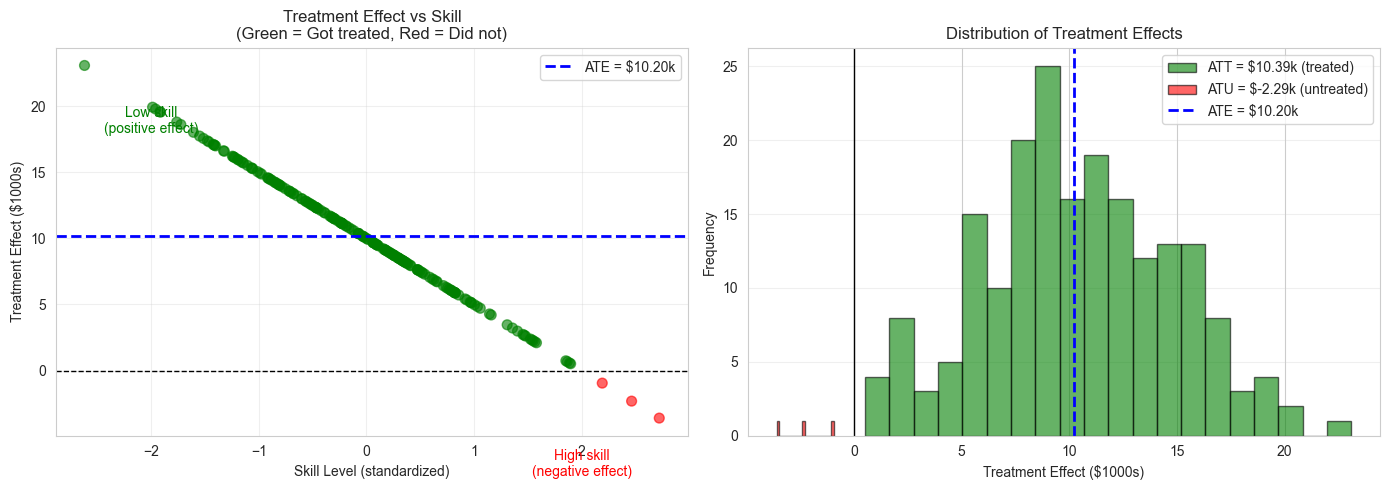

In [5]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Treatment effect vs skill
colors = ['green' if t == 1 else 'red' for t in T]
axes[0].scatter(skill, treatment_effect, c=colors, alpha=0.6, s=50)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].axhline(true_ATE, color='blue', linestyle='--', linewidth=2, label=f'ATE = ${true_ATE:.2f}k')
axes[0].set_xlabel('Skill Level (standardized)')
axes[0].set_ylabel('Treatment Effect ($1000s)')
axes[0].set_title('Treatment Effect vs Skill\n(Green = Got treated, Red = Did not)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add text annotations
axes[0].text(-2, 18, 'Low skill\n(positive effect)', ha='center', fontsize=10, color='green')
axes[0].text(2, -8, 'High skill\n(negative effect)', ha='center', fontsize=10, color='red')

# Right: Distribution comparison
axes[1].hist(treatment_effect[T == 1], bins=20, alpha=0.6, color='green', 
             label=f'ATT = ${ATT:.2f}k (treated)', edgecolor='black')
axes[1].hist(treatment_effect[T == 0], bins=20, alpha=0.6, color='red', 
             label=f'ATU = ${ATU:.2f}k (untreated)', edgecolor='black')
axes[1].axvline(true_ATE, color='blue', linestyle='--', linewidth=2, label=f'ATE = ${true_ATE:.2f}k')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Treatment Effect ($1000s)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Treatment Effects')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Discussion**:
- **Heterogeneous effects** mean different people benefit differently
- Treatment can help some and hurt others simultaneously
- **ATE** averages over everyone, hiding important variation
- **ATT** ≠ **ATE** when people select based on their individual effects
- This is why **targeting** matters: give treatment to those who benefit most
- Real-world: personalized medicine, targeted job training, customized marketing

---

## Solution 4: Three Treatment Levels

In [ ]:
# Solution to Exercise 4
np.random.seed(42)

# Step 1: Generate three potential outcomes
n = 300
Y0 = np.random.normal(35, 5, n)  # No training
Y1 = Y0 + np.random.normal(3, 1, n)  # Basic training (2 weeks)
Y2 = Y0 + np.random.normal(7, 1.5, n)  # Advanced training (6 weeks)

# Step 2: Count potential outcomes and comparisons
print("POTENTIAL OUTCOMES WITH 3 TREATMENTS:\n")
print(f"Number of potential outcomes per person: 3")
print(f"  Y(0): No training")
print(f"  Y(1): Basic training")
print(f"  Y(2): Advanced training")

print(f"\nNumber of pairwise comparisons: 3")
print(f"  1. Y(1) - Y(0): Basic vs None")
print(f"  2. Y(2) - Y(0): Advanced vs None")
print(f"  3. Y(2) - Y(1): Advanced vs Basic")

# Step 3: Calculate true pairwise ATEs
true_ATE_1_0 = (Y1 - Y0).mean()  # Basic vs None
true_ATE_2_0 = (Y2 - Y0).mean()  # Advanced vs None
true_ATE_2_1 = (Y2 - Y1).mean()  # Advanced vs Basic

print(f"\nTRUE PAIRWISE ATEs:")
print(f"  E[Y(1) - Y(0)] = ${true_ATE_1_0:.2f}k (Basic vs None)")
print(f"  E[Y(2) - Y(0)] = ${true_ATE_2_0:.2f}k (Advanced vs None)")
print(f"  E[Y(2) - Y(1)] = ${true_ATE_2_1:.2f}k (Advanced vs Basic)")

# Verify transitivity
print(f"\nTransitivity check: ATE(2,0) = ATE(2,1) + ATE(1,0)")
print(f"  ${true_ATE_2_0:.2f}k ≈ ${true_ATE_2_1:.2f}k + ${true_ATE_1_0:.2f}k = ${true_ATE_2_1 + true_ATE_1_0:.2f}k ✓")

# Step 4: Randomly assign treatment
T = np.random.choice([0, 1, 2], size=n, p=[1/3, 1/3, 1/3])

# Observe outcomes
Y_obs = np.where(T == 0, Y0, np.where(T == 1, Y1, Y2))

print(f"\nTREATMENT ASSIGNMENT:")
print(f"  % in T=0 (None):     {(T == 0).mean() * 100:.1f}%")
print(f"  % in T=1 (Basic):    {(T == 1).mean() * 100:.1f}%")
print(f"  % in T=2 (Advanced): {(T == 2).mean() * 100:.1f}%")

# Step 5: Estimate pairwise ATEs from data
est_ATE_1_0 = Y_obs[T == 1].mean() - Y_obs[T == 0].mean()
est_ATE_2_0 = Y_obs[T == 2].mean() - Y_obs[T == 0].mean()
est_ATE_2_1 = Y_obs[T == 2].mean() - Y_obs[T == 1].mean()

print(f"\nESTIMATED PAIRWISE ATEs (from observed data):")
print(f"  Est[Y(1) - Y(0)] = ${est_ATE_1_0:.2f}k  (True: ${true_ATE_1_0:.2f}k)")
print(f"  Est[Y(2) - Y(0)] = ${est_ATE_2_0:.2f}k  (True: ${true_ATE_2_0:.2f}k)")
print(f"  Est[Y(2) - Y(1)] = ${est_ATE_2_1:.2f}k  (True: ${true_ATE_2_1:.2f}k)")

print(f"\n✓ All three pairwise ATEs can be recovered from randomized data!")
print(f"   (Small differences due to sampling variation)")

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Distribution by treatment group
for t, label, color in [(0, 'T=0 (None)', 'red'), 
                         (1, 'T=1 (Basic)', 'orange'), 
                         (2, 'T=2 (Advanced)', 'green')]:
    axes[0].hist(Y_obs[T == t], bins=20, alpha=0.5, label=label, 
                 color=color, edgecolor='black')
axes[0].set_xlabel('Observed Earnings ($1000s)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Observed Outcomes by Treatment')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Right: Estimated vs True ATEs
comparisons = ['Basic\nvs\nNone', 'Advanced\nvs\nNone', 'Advanced\nvs\nBasic']
true_ates = [true_ATE_1_0, true_ATE_2_0, true_ATE_2_1]
est_ates = [est_ATE_1_0, est_ATE_2_0, est_ATE_2_1]

x_pos = np.arange(len(comparisons))
width = 0.35

axes[1].bar(x_pos - width/2, true_ates, width, label='True ATE', 
            color='steelblue', alpha=0.7, edgecolor='black')
axes[1].bar(x_pos + width/2, est_ates, width, label='Estimated ATE', 
            color='coral', alpha=0.7, edgecolor='black')

axes[1].set_xlabel('Comparison')
axes[1].set_ylabel('Treatment Effect ($1000s)')
axes[1].set_title('Pairwise Treatment Effects: True vs Estimated')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparisons)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Discussion**:
- With **K treatments**, each person has **K potential outcomes**
- Number of pairwise comparisons: **K choose 2** = K(K-1)/2
  - For K=3: 3 comparisons
  - For K=4: 6 comparisons
  - For K=10: 45 comparisons!
- **Random assignment** allows us to estimate all pairwise ATEs
- **Transitivity**: ATE(2,0) = ATE(2,1) + ATE(1,0) should hold
- Real-world: multiple drug doses, different program intensities, policy variants
- Challenge: Need larger samples to estimate many pairwise comparisons precisely

---

## Summary

You've now seen complete solutions to all exercises! Key takeaways:

1. **Selection bias can go either direction** - Depends on who selects into treatment
2. **Bias ≠ Variance** - Randomization eliminates bias; larger samples reduce variance
3. **Heterogeneity matters** - ATE can hide important variation; ATT ≠ ATE ≠ ATU
4. **Framework extends naturally** - Multiple treatments increase complexity but maintain core logic

These concepts are fundamental to all of causal inference!

---

**Next**: Return to [DAGs Basics](../03_dags_basics.ipynb) to learn about causal graphs